<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/02_angle_geometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 2 — Geometry: angle error

Replace the generic logistic curve with a one-parameter model derived from the geometry of a ball entering a cup. Fit it to the Berry data, then test the already-fit model on the later Broadie data **without refitting**.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/berry_1996_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,2,1443,1346,0.932779
1,3,694,577,0.831412
2,4,455,337,0.740659
3,5,353,208,0.589235
4,6,272,149,0.547794
5,7,256,136,0.531250
6,8,240,111,0.462500
7,9,217,69,0.317972
8,10,200,67,0.335000
9,11,237,75,0.316456


In [ ]:
def plot_rate(draws, data, title, *, median_label="median", show_observed=True, ylim=(-0.05, 1.05), show_bounds=False):
    """Plot a probability/rate relationship against continuous putting distance."""
    x = data["distance_ft"].to_numpy()
    curve_dim = next(dim for dim in draws.dims if dim not in ("chain", "draw"))
    order = np.argsort(x)
    draws = draws.isel({curve_dim: order})
    x = x[order]

    median = draws.median(dim=("chain", "draw"))
    interval = draws.azstats.hdi(prob=0.90)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(
        x,
        interval.sel(ci_bound="lower"),
        interval.sel(ci_bound="upper"),
        alpha=0.22,
        label="90% HDI",
    )
    ax.plot(x, median, label=median_label)
    if show_observed:
        ax.scatter(x, data["rate"].to_numpy()[order], s=30, color="black", label="observed")
    if show_bounds:
        ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
        ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Proportion made",
        title=title,
    )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8, frameon=False)
    return ax

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model from first principles

If a golfer aims straight but the actual direction has Normal angular error with standard deviation $\sigma_{angle}$, a putt from distance $x$ succeeds when the angular error stays within

$$
\theta(x)=\arcsin\!\left(\frac{R-r}{x}\right).
$$

Thus

$$
p(x)=2\Phi\!\left(\frac{\theta(x)}{\sigma_{angle}}\right)-1.
$$

We put the prior directly on $\sigma_{angle}$ in **degrees**.

In [ ]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_base = pm.Deterministic(
        "p_base",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    made = pm.Binomial(
        "made",
        n=attempts,
        p=p_base,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

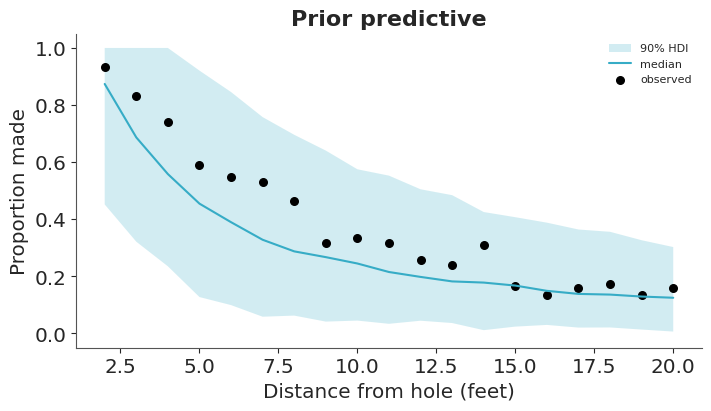

In [6]:
plot_rate(
    prior["prior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Prior predictive",
);

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Output()

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_deg,1.53,0.02,1.49,1.56,1367.19,1936.84,1.0,0.0,0.0


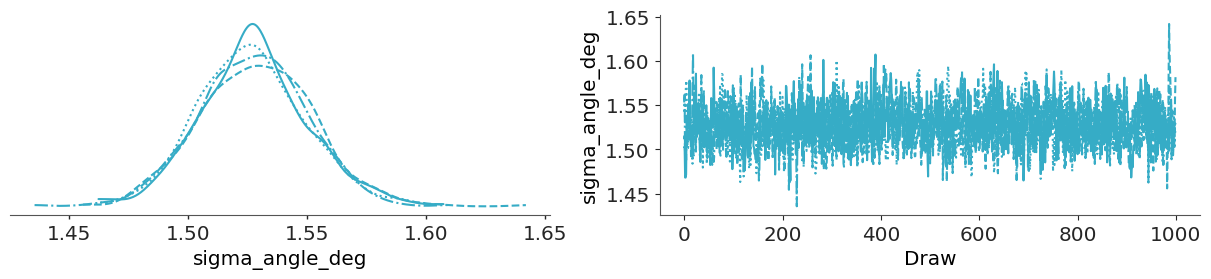

In [8]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg']);

## Posterior fit

This plot shows posterior uncertainty in the continuous mechanistic success-probability relationship $p_{base}(x)$. It does not include the additional variation in newly observed successes.

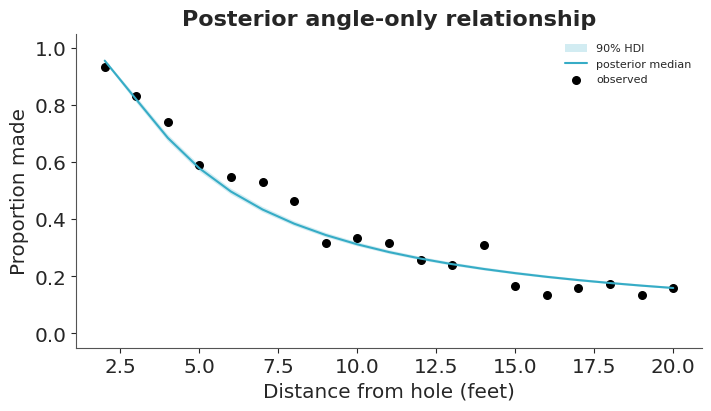

In [9]:
plot_rate(
    idata["posterior"]["p_base"],
    golf,
    "Posterior angle-only relationship",
    median_label="posterior median",
);

## Posterior predictive check

Now generate new outcomes at the same putting distances from the fitted model. This uses the same graphical grammar as the prior predictive check; the difference is that these predictions are conditioned on the observed data.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Output()

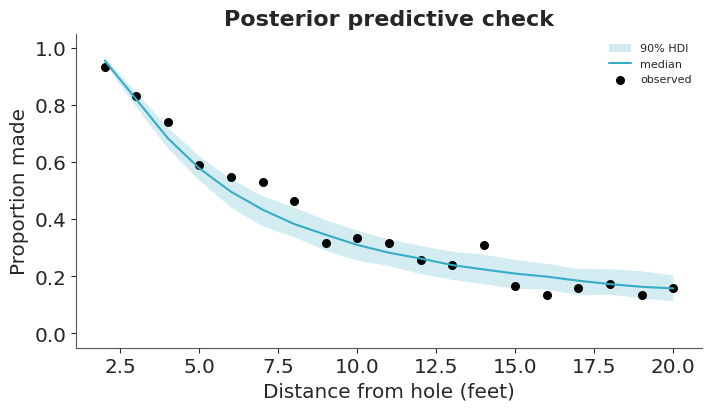

In [11]:
plot_rate(
    idata["posterior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Posterior predictive check",
);

## Model criticism

These residuals compare the observed rates with the posterior-median mechanistic relationship $p_{base}(x)$. They are a check for systematic structure in the mechanism, not a posterior predictive interval.

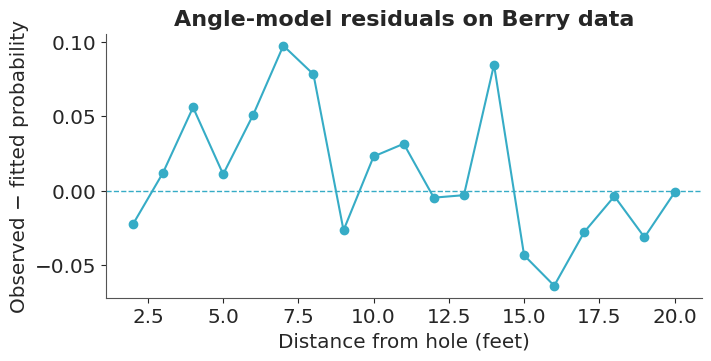

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Angle-model residuals on Berry data");

## External check on newer data

Now use the posterior learned from the Berry data to predict the Broadie observations. We do **not** condition on the new outcomes.

In [13]:
new_golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
new_golf["rate"] = new_golf["made"] / new_golf["attempts"]

new_coords = {"obs_id": new_golf["distance_ft"].to_numpy()}
with pm.Model(coords=new_coords) as prediction_model:
    distance = pm.Data("distance_new", new_golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts_new", new_golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_new = 2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1
    made_new = pm.Binomial("made_new", n=attempts, p=p_new, dims="obs_id")

    predictions = pm.sample_posterior_predictive(
        idata,
        predictions=True,
        var_names=["made_new"],
        freeze_vars=["sigma_angle_deg"],
        random_seed=RANDOM_SEED,
    )

Output()

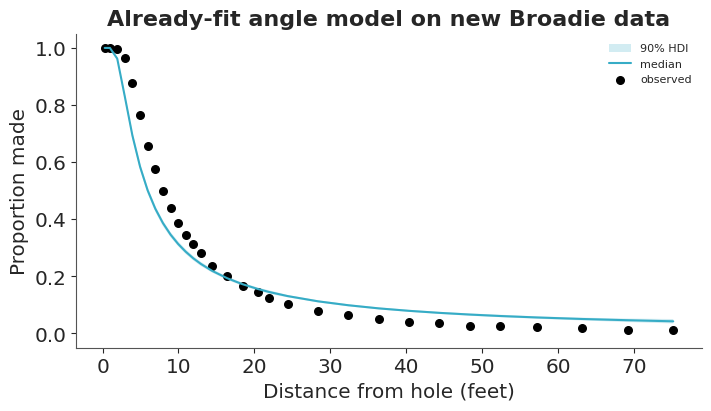

In [14]:
plot_rate(
    predictions["predictions"]["made_new"] / new_golf["attempts"].to_numpy(),
    new_golf,
    "Already-fit angle model on new Broadie data",
);

## Decision: reject for the new prediction problem

The newer data have substantially higher short-putt success and, beyond about 20 feet, lower success than the old angle-only model predicts. That is an **external predictive failure**, not merely an in-sample residual. A plausible missing mechanism is distance control: long putts can miss by being hit the wrong distance even when their angle is good. **Next notebook:** add distance error.